# Exploratory Data Analysis and Sampling Strategy

## Project Objective
The goal of this analysis is to explore the relationships between student lifestyle, academic, and behavioral factors and the level of depression.

## Target Variable
The target variable selected for this analysis is `depression`.

## Research Question
Which academic, behavioral, and lifestyle factors are most associated with depression among students?

## Hypotheses
1. Higher stress levels are associated with higher depression levels.
2. Lower sleep hours are associated with higher depression levels.
3. Higher social media usage and screen time are associated with higher depression levels.
4. Better motivation, concentration, and self-discipline are associated with lower depression levels.
5. Since the target variable is continuous, the dataset will be treated as a regression problem.

## Step 1: Import Libraries
In this step, the required Python libraries are imported for data loading, inspection, visualization, and sampling.

In [240]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2: Load the Dataset
The dataset is loaded into a pandas DataFrame so it can be inspected and analyzed.

In [241]:
df = pd.read_csv(r"C:\Users\samak\Desktop\Machinelearning project\college_students_habits_1M.csv")

## Step 3: Inspect the Dataset Structure
This step is used to understand the dataset size, column names, data types, and a preview of the first rows.
This helps identify the target variable, feature types, and whether the dataset contains time or group-related columns.

In [242]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

Shape of dataset: (1000000, 42)

Columns:
['study_hours', 'attendance', 'assignment_completion', 'midterm_score', 'final_score', 'project_score', 'backlogs', 'sleep_hours', 'stress', 'anxiety', 'depression', 'motivation', 'concentration', 'time_management', 'self_discipline', 'social_media_hours', 'gaming_hours', 'netflix_hours', 'screen_time', 'physical_activity', 'junk_food_frequency', 'caffeine_mg', 'late_night_frequency', 'procrastination_score', 'family_income', 'parental_education_level', 'internet_quality', 'library_visits', 'online_courses_completed', 'part_time_hours', 'peer_study_group', 'relationship_status', 'hostel_student', 'extracurricular_hours', 'phone_unlocks_per_day', 'previous_gpa', 'class_participation', 'weekly_study_sessions', 'group_study_hours', 'financial_stress', 'gpa', 'performance_level']

First 5 rows:
   study_hours  attendance  assignment_completion  midterm_score  final_score  \
0     3.014684    67.00599              51.595387      57.211285    61.6535

## Step 4: Define the Target Variable
The target variable for this analysis is `depression`, which represents the depression level of students.
This target will be examined to determine whether the problem should be treated as classification or regression.

In [243]:
target_col = "depression"
print("Target column:", target_col)

Target column: depression


## Step 5: Check Missing Values
Missing values are examined to understand the quality of the dataset and to determine whether preprocessing is needed before sampling and deeper analysis.

In [244]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nMissing value percentage:")
print((df.isnull().mean() * 100).round(2))

Missing values per column:
study_hours                    0
attendance                     0
assignment_completion          0
midterm_score                  0
final_score                    0
project_score                  0
backlogs                       0
sleep_hours                    0
stress                         0
anxiety                        0
depression                     0
motivation                     0
concentration                  0
time_management                0
self_discipline                0
social_media_hours             0
gaming_hours                   0
netflix_hours                  0
screen_time                    0
physical_activity              0
junk_food_frequency            0
caffeine_mg                    0
late_night_frequency           0
procrastination_score          0
family_income                  0
parental_education_level       0
internet_quality               0
library_visits                 0
online_courses_completed       0
part_time_hours 

## Step 6: Check for Duplicate Rows
Duplicate rows are checked because they may bias the analysis and affect the representativeness of the sample.

In [245]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## Step 7: Examine the Target Variable
This step is used to understand the nature of the target variable.
If the target has many numeric values, the problem is treated as regression.
If the target contains a few categories, the problem is treated as classification.

In [246]:
print("Target data type:", df[target_col].dtype)
print("\nNumber of unique values in target:", df[target_col].nunique())

print("\nTarget summary statistics:")
print(df[target_col].describe())

Target data type: float64

Number of unique values in target: 964263

Target summary statistics:
count    1000000.000000
mean          44.991453
std           14.991202
min            0.000000
25%           34.862051
50%           44.973913
75%           55.099820
max          100.000000
Name: depression, dtype: float64


## Step 8: Visualize the Distribution of the Target
A histogram is plotted to understand the distribution of depression values.
This helps determine whether the target is continuous and whether the distribution is skewed or approximately normal.

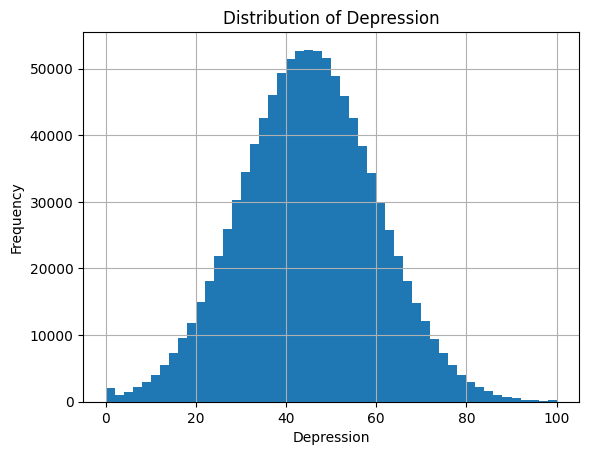

In [247]:
df[target_col].hist(bins=50)
plt.title("Distribution of Depression")
plt.xlabel("Depression")
plt.ylabel("Frequency")
plt.show()

## Step 9: Identify the Problem Type
Based on the number of unique values and the histogram of the target variable, `depression` is treated as a continuous variable.
Therefore, this analysis is considered a regression problem rather than a classification problem.

In [248]:
if df[target_col].nunique() > 20:
    print("The target variable is continuous. This is a regression problem.")
else:
    print("The target variable is categorical. This is a classification problem.")

The target variable is continuous. This is a regression problem.


## Step 10: Check for Time Structure
This step checks whether the dataset contains time-related columns such as dates or timestamps.
If such columns exist and row order matters, time-based sampling may be required.

In [249]:
print("Columns:")
print(df.columns.tolist())

Columns:
['study_hours', 'attendance', 'assignment_completion', 'midterm_score', 'final_score', 'project_score', 'backlogs', 'sleep_hours', 'stress', 'anxiety', 'depression', 'motivation', 'concentration', 'time_management', 'self_discipline', 'social_media_hours', 'gaming_hours', 'netflix_hours', 'screen_time', 'physical_activity', 'junk_food_frequency', 'caffeine_mg', 'late_night_frequency', 'procrastination_score', 'family_income', 'parental_education_level', 'internet_quality', 'library_visits', 'online_courses_completed', 'part_time_hours', 'peer_study_group', 'relationship_status', 'hostel_student', 'extracurricular_hours', 'phone_unlocks_per_day', 'previous_gpa', 'class_participation', 'weekly_study_sessions', 'group_study_hours', 'financial_stress', 'gpa', 'performance_level']


### Conclusion
No time-related columns such as `date`, `timestamp`, or `created_at` were found in the dataset.
Therefore, the dataset does not have temporal structure, and time-based sampling is not required.

## Step 11: Check for Group Structure
This step checks whether the dataset contains identifier columns such as `student_id`, `user_id`, or `customer_id`.
If multiple rows belong to the same entity, group-aware sampling may be necessary.

In [250]:
print("Columns:")
print(df.columns.tolist())

Columns:
['study_hours', 'attendance', 'assignment_completion', 'midterm_score', 'final_score', 'project_score', 'backlogs', 'sleep_hours', 'stress', 'anxiety', 'depression', 'motivation', 'concentration', 'time_management', 'self_discipline', 'social_media_hours', 'gaming_hours', 'netflix_hours', 'screen_time', 'physical_activity', 'junk_food_frequency', 'caffeine_mg', 'late_night_frequency', 'procrastination_score', 'family_income', 'parental_education_level', 'internet_quality', 'library_visits', 'online_courses_completed', 'part_time_hours', 'peer_study_group', 'relationship_status', 'hostel_student', 'extracurricular_hours', 'phone_unlocks_per_day', 'previous_gpa', 'class_participation', 'weekly_study_sessions', 'group_study_hours', 'financial_stress', 'gpa', 'performance_level']


### Conclusion
No group identifier column such as `student_id` or `user_id` was found in the dataset.
This suggests that each row represents an independent observation rather than repeated measurements of the same student.
Therefore, group-based sampling is not required.

## Step 12: Sampling Decision
The following conclusions were drawn from the exploratory checks:

- The target variable `depression` is continuous.
- The dataset does not contain time-related columns.
- The dataset does not contain group identifier columns.
- The observations appear to be independent.
- There is no special structure that must be preserved during sampling.

Based on these findings, simple random sampling is the most appropriate sampling method for this dataset.

## Step 13: Apply Simple Random Sampling
Simple random sampling is applied to select a representative subset of the dataset.
This method is appropriate because the data is not grouped, not time-ordered, and the target variable is continuous.

In [251]:
sample_size = min(100000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)
print("Original shape:", df.shape)
print("Sample shape:", df_sample.shape)

Original shape: (1000000, 42)
Sample shape: (100000, 42)


## Step 14: Validate the Sample
The sample is compared to the full dataset using summary statistics of the target variable.
If the statistics are close, the sample can be considered reasonably representative.

In [252]:
print("Original shape:", df.shape)
print("Sample shape:", df_sample.shape)

print("\nOriginal depression mean:", df[target_col].mean())
print("Sample depression mean:", df_sample[target_col].mean())

print("\nOriginal depression std:", df[target_col].std())
print("Sample depression std:", df_sample[target_col].std())

Original shape: (1000000, 42)
Sample shape: (100000, 42)

Original depression mean: 44.99145297219754
Sample depression mean: 44.951999642673805

Original depression std: 14.991202051679972
Sample depression std: 15.055963305613217


## Step 15: Compare the Original and Sample Distributions
A visual comparison is made between the target distribution in the original dataset and in the sampled dataset.
This helps confirm whether the sample preserves the overall shape of the data.

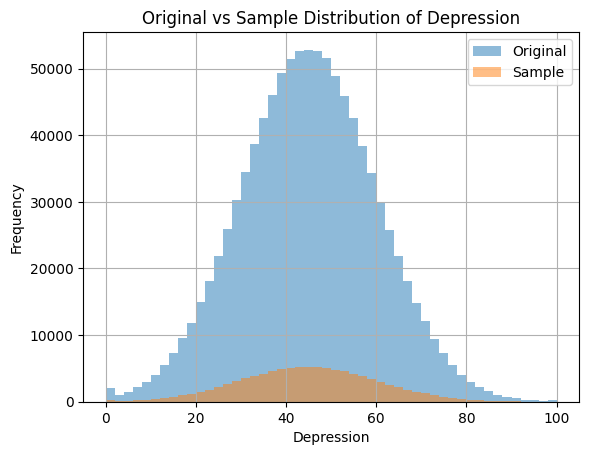

In [253]:
df[target_col].hist(bins=50, alpha=0.5, label="Original")
df_sample[target_col].hist(bins=50, alpha=0.5, label="Sample")
plt.title("Original vs Sample Distribution of Depression")
plt.xlabel("Depression")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Step 16: Check Data Quality in the Sample

After validating that the sample preserves the main characteristics of the original dataset, the sampled data is checked for duplicate rows, missing values, and basic summary statistics before continuing with exploratory data analysis.

In [254]:
print("Duplicate rows in sample:", df_sample.duplicated().sum())

print("\nMissing values per column:")
print(df_sample.isnull().sum())

print("\nMissing value percentage per column:")
print((df_sample.isnull().mean() * 100).round(2))

print("\nSample summary statistics:")
print(df_sample.describe())

Duplicate rows in sample: 0

Missing values per column:
study_hours                   0
attendance                    0
assignment_completion         0
midterm_score                 0
final_score                   0
project_score                 0
backlogs                      0
sleep_hours                   0
stress                        0
anxiety                       0
depression                    0
motivation                    0
concentration                 0
time_management               0
self_discipline               0
social_media_hours            0
gaming_hours                  0
netflix_hours                 0
screen_time                   0
physical_activity             0
junk_food_frequency           0
caffeine_mg                   0
late_night_frequency          0
procrastination_score         0
family_income                 0
parental_education_level      0
internet_quality              0
library_visits                0
online_courses_completed      0
part_time_hours 

Step 17: Summary statistics for numeric features

In [255]:
df_sample.describe()

,study_hours,attendance,assignment_completion,midterm_score,final_score,project_score,backlogs,sleep_hours,stress,anxiety,...,relationship_status,hostel_student,extracurricular_hours,phone_unlocks_per_day,previous_gpa,class_participation,weekly_study_sessions,group_study_hours,financial_stress,gpa
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,4.043751,74.878878,69.877046,60.028557,64.874951,67.988508,2.551390,6.500258,3.209195,49.946445,...,0.309250,0.500560,2.997378,60.071956,6.002856,5.008427,3.003470,2.513111,4.997486,0.831225
std,2.215836,12.906304,14.691109,14.993749,17.635051,13.900629,1.652116,0.435375,1.762499,15.066987,...,0.462187,0.500002,0.999865,19.839960,1.499375,1.715290,1.001898,1.417110,1.343626,0.295493
min,0.000000,30.000000,20.000000,0.000000,0.000000,11.646010,0.000000,4.540363,1.000000,0.000000,...,0.000000,0.000000,0.000000,10.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,2.454498,66.094832,59.958107,49.849120,52.818943,58.525847,1.000000,6.207465,1.673351,39.754795,...,0.000000,0.000000,2.324683,46.601444,4.984912,3.834894,2.323275,1.323275,4.084566,0.627221
50%,4.006315,75.025745,69.978675,60.051690,65.062025,68.048245,2.000000,6.499275,3.039484,49.900767,...,0.000000,1.000000,2.996563,60.060502,6.005169,5.000496,3.003446,3.003446,4.995222,0.830306
75%,5.554584,84.002345,80.071855,70.208469,77.250163,77.527900,4.000000,6.793636,4.416483,60.116198,...,1.000000,1.000000,3.672931,73.527968,7.020847,6.175960,3.680565,3.680565,5.904129,1.033114
max,12.000000,100.000000,100.000000,100.000000,100.000000,100.000000,10.000000,8.484711,10.000000,100.000000,...,1.000000,1.000000,7.207886,145.591800,10.000000,10.000000,7.588564,7.588564,10.000000,1.997882


Step 18: Study correlations with depression

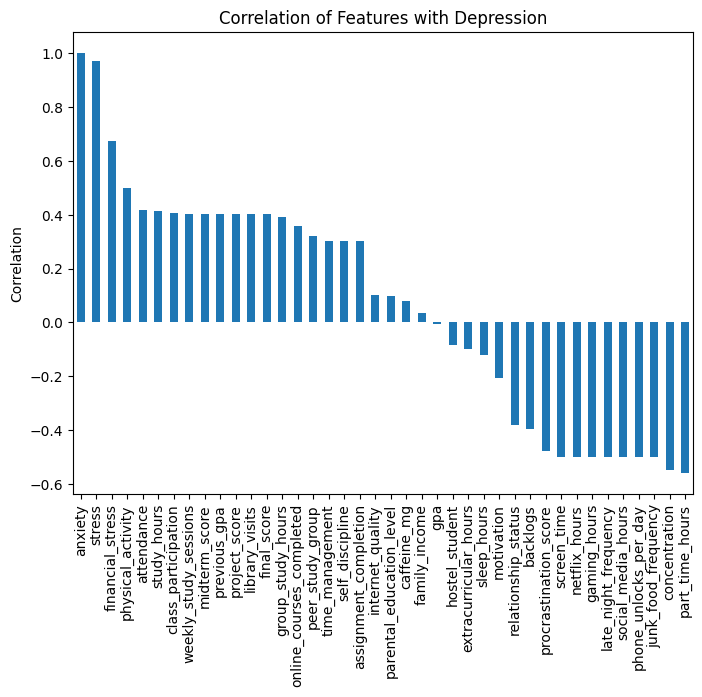

In [256]:
plt.figure(figsize=(8,6))
corr_target.drop("depression").plot(kind="bar")
plt.title("Correlation of Features with Depression")
plt.ylabel("Correlation")
plt.show()

## Correlation Analysis Results

The correlation analysis shows that several variables have strong relationships with depression.

Strong positive correlations were observed with anxiety, stress, and financial stress, indicating that higher levels of these factors are associated with higher depression levels.

On the other hand, variables such as sleep hours, physical activity, motivation, and self-discipline showed negative correlations with depression, suggesting that higher values of these variables are associated with lower depression levels.

These results support the initial hypotheses, particularly the relationship between stress, sleep, and depression.

It is important to note that correlation does not imply causation, but it helps identify important factors for further analysis.

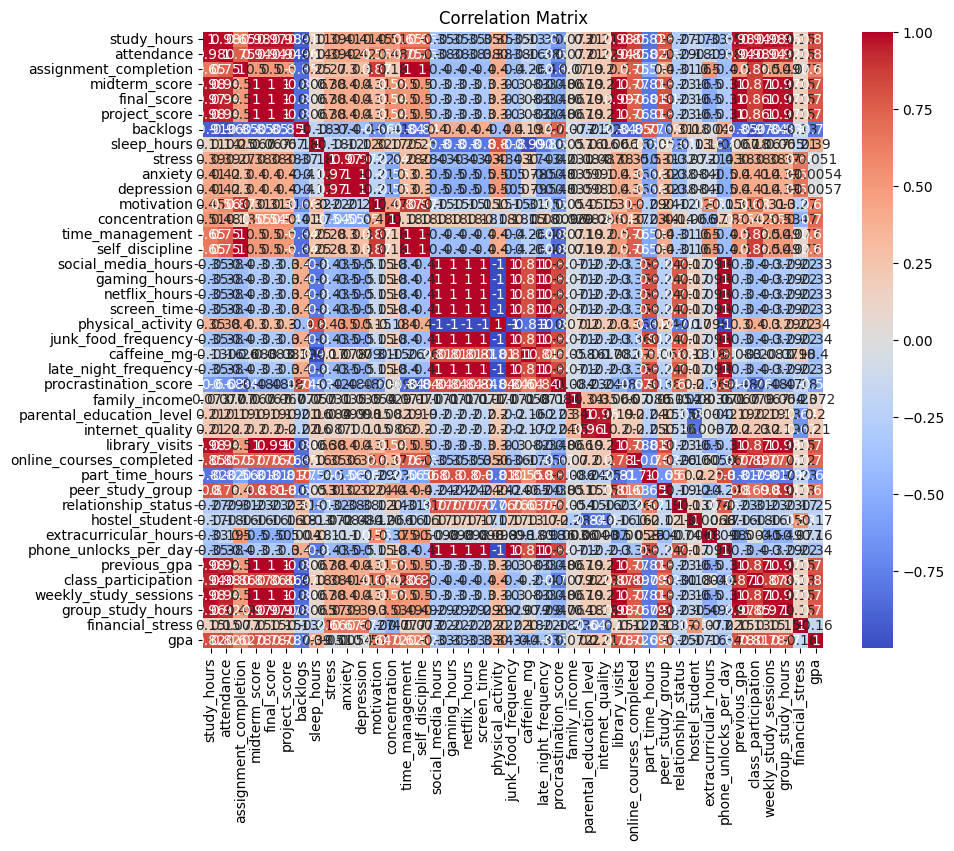

In [280]:
corr = df_sample.corr(numeric_only=True)

import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

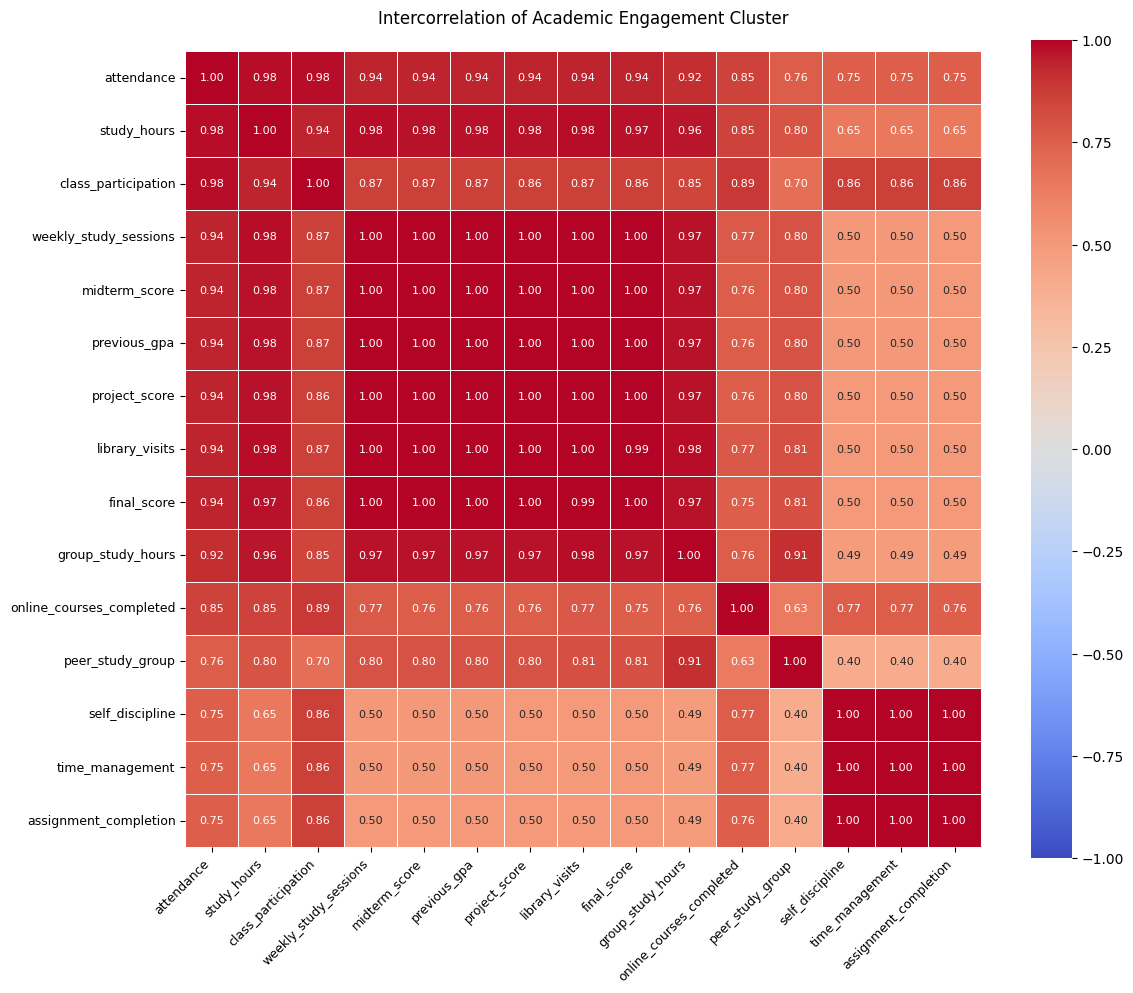

In [281]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster = ['attendance', 'study_hours', 'class_participation',
           'weekly_study_sessions', 'midterm_score', 'previous_gpa',
           'project_score', 'library_visits', 'final_score',
           'group_study_hours', 'online_courses_completed',
           'peer_study_group', 'self_discipline', 'time_management',
           'assignment_completion']

corr_matrix = df[cluster].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)

plt.title('Intercorrelation of Academic Engagement Cluster', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

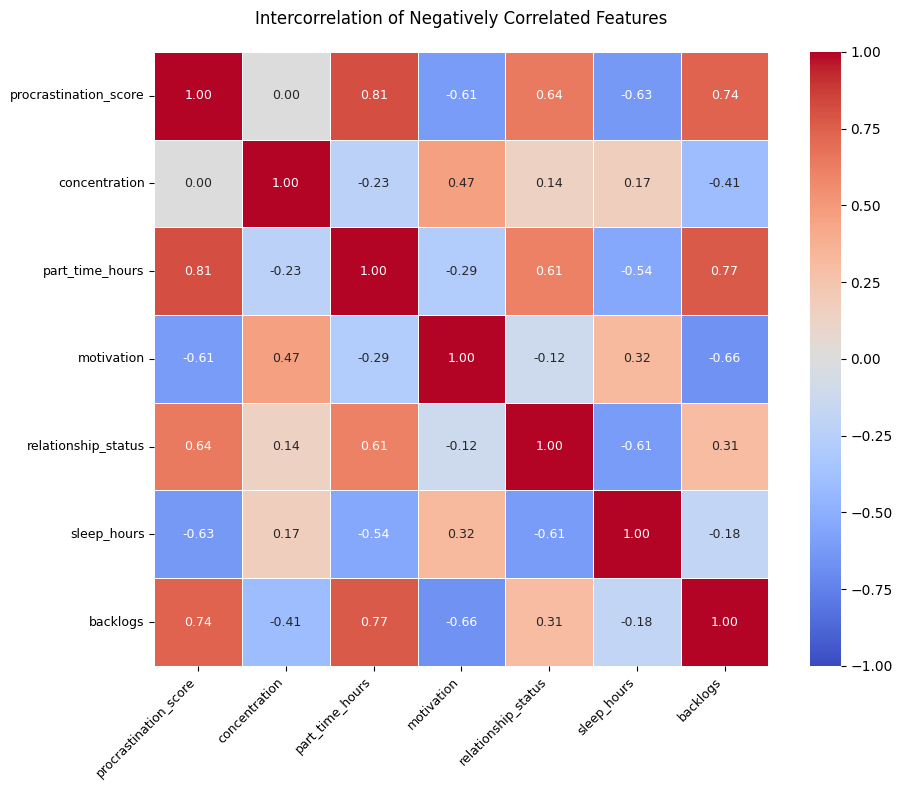

In [283]:
import seaborn as sns
import matplotlib.pyplot as plt

negative_features = [
    'procrastination_score',
    'concentration',
    'part_time_hours',
    'motivation',
    'relationship_status',
    'sleep_hours',
    'backlogs',
]

corr_matrix = df[negative_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 9}
)

plt.title('Intercorrelation of Negatively Correlated Features', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## Step 18: Visualize Key Relationships

After identifying the most important variables through correlation analysis, scatter plots are used to visually examine the relationships between these variables and the target variable `depression`.

This step helps confirm whether the relationships observed in the correlation analysis are consistent and meaningful.

### Key Variables Selected:
- Stress
- Anxiety
- Sleep Hours
- Social Media Hours
- Screen Time
- Motivation

These variables were selected because they showed strong positive or negative correlations with depression.

Scatter plots allow us to observe:
- The direction of the relationship (positive or negative)
- The strength and spread of the relationship
- Any visible patterns or trends in the data

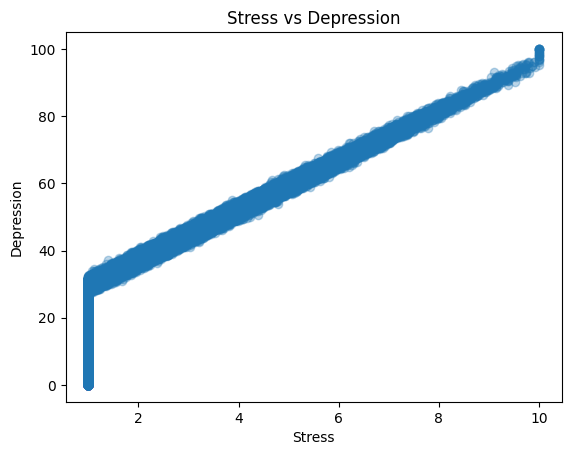

In [257]:
plt.scatter(df_sample["stress"], df_sample["depression"], alpha=0.3)
plt.title("Stress vs Depression")
plt.xlabel("Stress")
plt.ylabel("Depression")
plt.show()

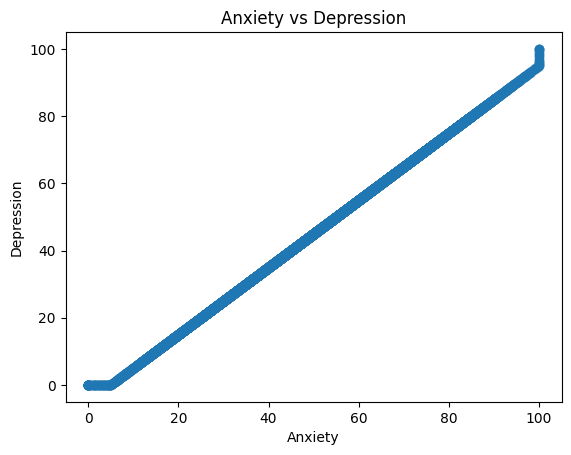

In [258]:
plt.scatter(df_sample["anxiety"], df_sample["depression"], alpha=0.3)
plt.title("Anxiety vs Depression")
plt.xlabel("Anxiety")
plt.ylabel("Depression")
plt.show()

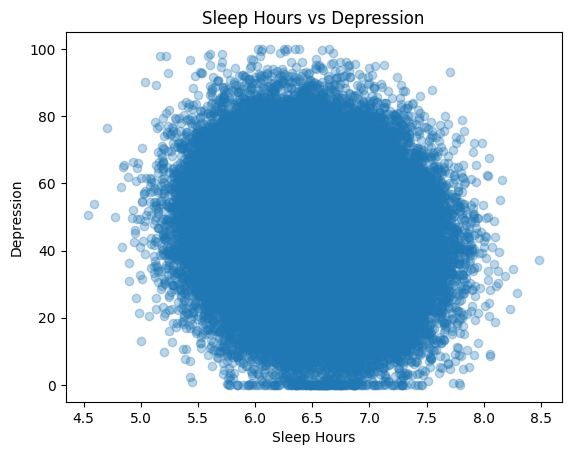

In [259]:
plt.scatter(df_sample["sleep_hours"], df_sample["depression"], alpha=0.3)
plt.title("Sleep Hours vs Depression")
plt.xlabel("Sleep Hours")
plt.ylabel("Depression")
plt.show()

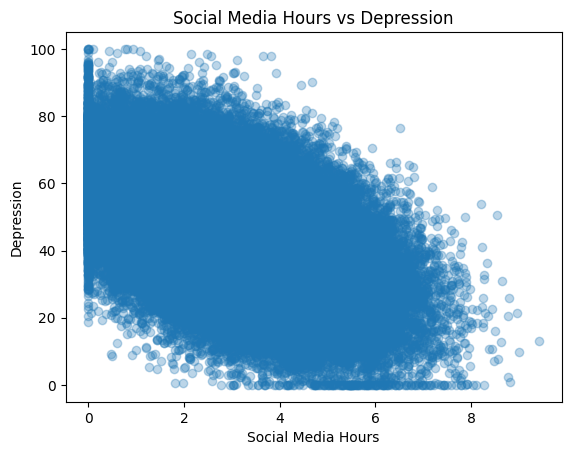

In [260]:
plt.scatter(df_sample["social_media_hours"], df_sample["depression"], alpha=0.3)
plt.title("Social Media Hours vs Depression")
plt.xlabel("Social Media Hours")
plt.ylabel("Depression")
plt.show()

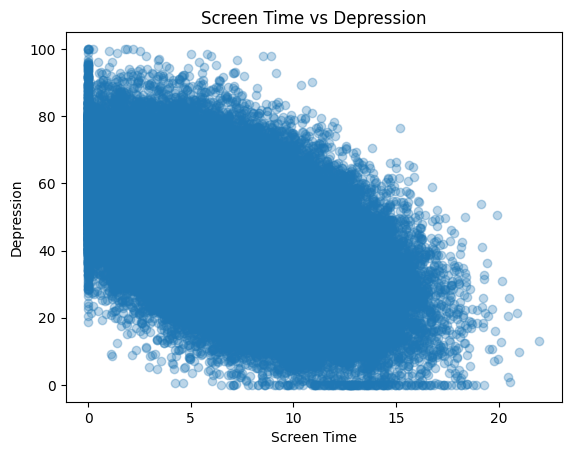

In [261]:
plt.scatter(df_sample["screen_time"], df_sample["depression"], alpha=0.3)
plt.title("Screen Time vs Depression")
plt.xlabel("Screen Time")
plt.ylabel("Depression")
plt.show()

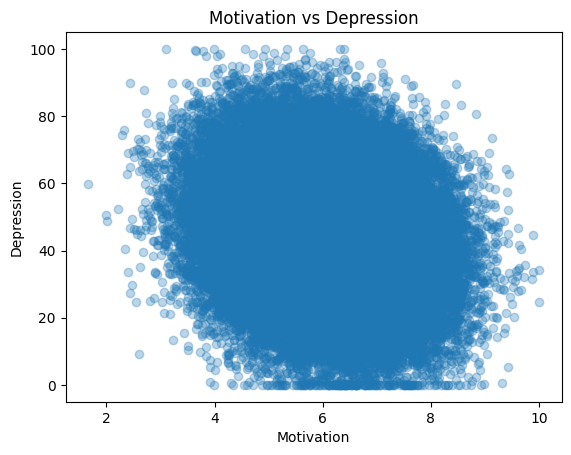

In [262]:
plt.scatter(df_sample["motivation"], df_sample["depression"], alpha=0.3)
plt.title("Motivation vs Depression")
plt.xlabel("Motivation")
plt.ylabel("Depression")
plt.show()

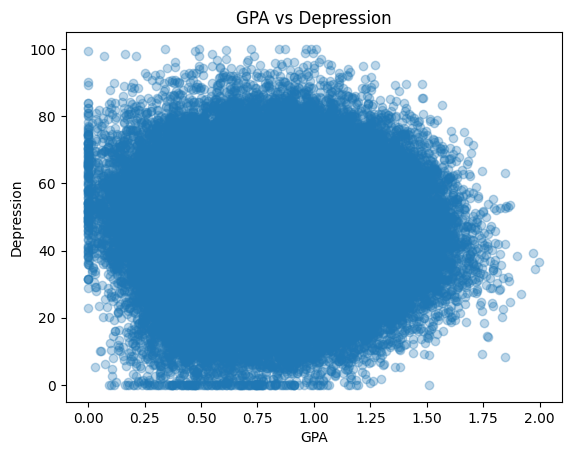

In [263]:
plt.scatter(df_sample["gpa"], df_sample["depression"], alpha=0.3)
plt.title("GPA vs Depression")
plt.xlabel("GPA")
plt.ylabel("Depression")
plt.show()

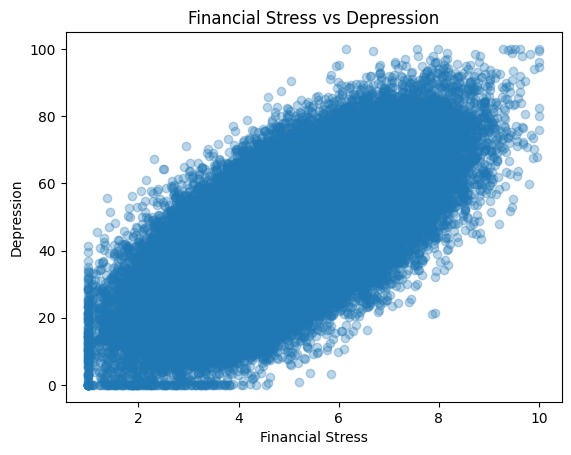

In [264]:
plt.scatter(df_sample["financial_stress"], df_sample["depression"], alpha=0.3)
plt.title("Financial Stress vs Depression")
plt.xlabel("Financial Stress")
plt.ylabel("Depression")
plt.show()

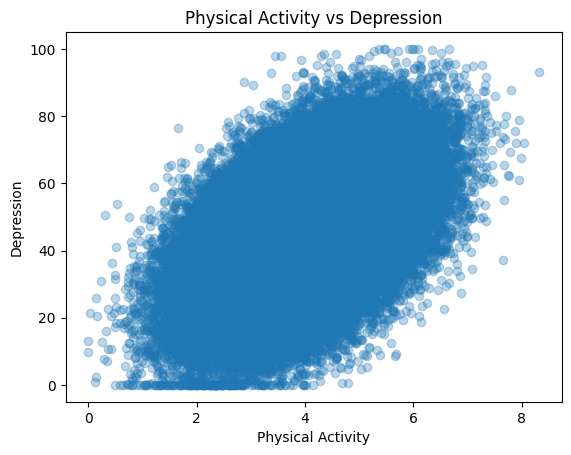

In [265]:
plt.scatter(df_sample["physical_activity"], df_sample["depression"], alpha=0.3)
plt.title("Physical Activity vs Depression")
plt.xlabel("Physical Activity")
plt.ylabel("Depression")
plt.show()

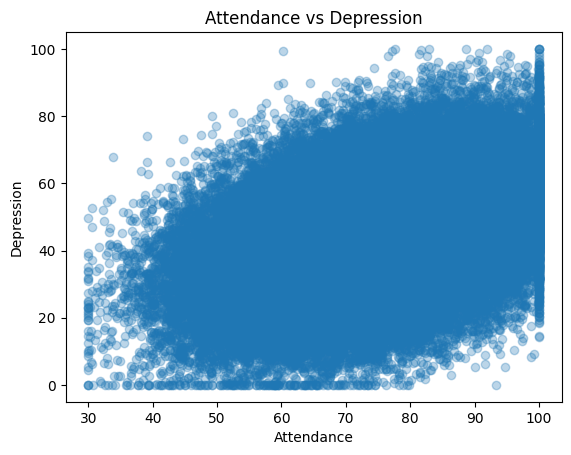

In [266]:
plt.scatter(df_sample["attendance"], df_sample["depression"], alpha=0.3)
plt.title("Attendance vs Depression")
plt.xlabel("Attendance")
plt.ylabel("Depression")
plt.show()

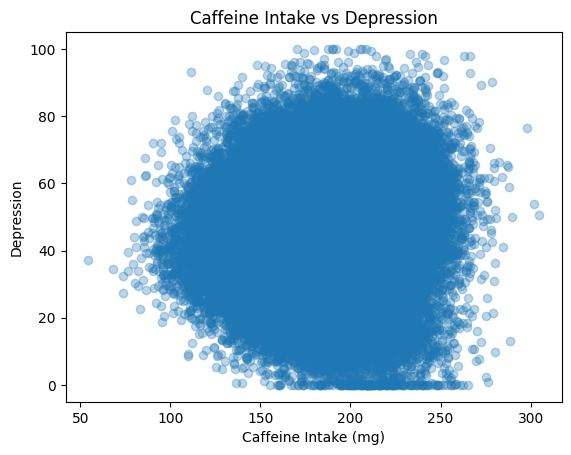

In [267]:
plt.scatter(df_sample["caffeine_mg"], df_sample["depression"], alpha=0.3)
plt.title("Caffeine Intake vs Depression")
plt.xlabel("Caffeine Intake (mg)")
plt.ylabel("Depression")
plt.show()

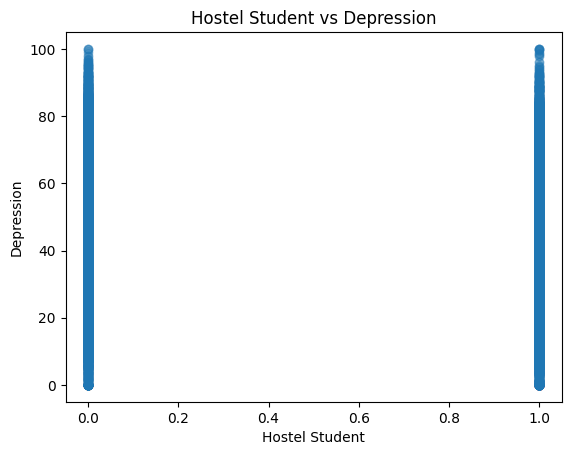

In [268]:
plt.scatter(df_sample["hostel_student"], df_sample["depression"], alpha=0.3)
plt.title("Hostel Student vs Depression")
plt.xlabel("Hostel Student")
plt.ylabel("Depression")
plt.show()

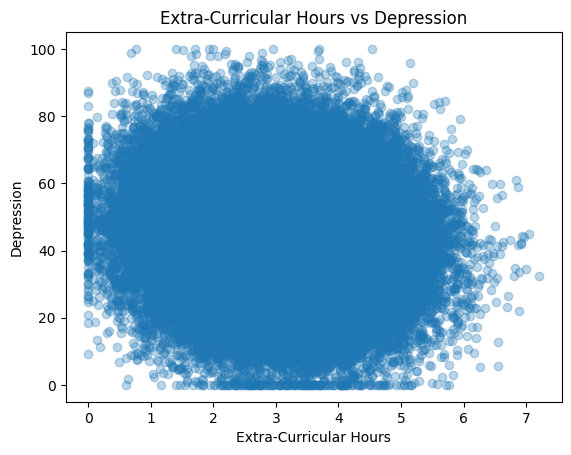

In [269]:
plt.scatter(df_sample["extracurricular_hours"], df_sample["depression"], alpha=0.3)
plt.title("Extra-Curricular Hours vs Depression")
plt.xlabel("Extra-Curricular Hours")
plt.ylabel("Depression")
plt.show()

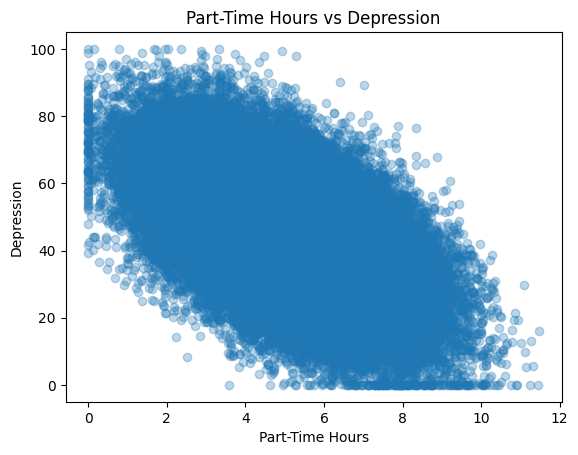

In [270]:
plt.scatter(df_sample["part_time_hours"], df_sample["depression"], alpha=0.3)
plt.title("Part-Time Hours vs Depression")
plt.xlabel("Part-Time Hours")
plt.ylabel("Depression")
plt.show()

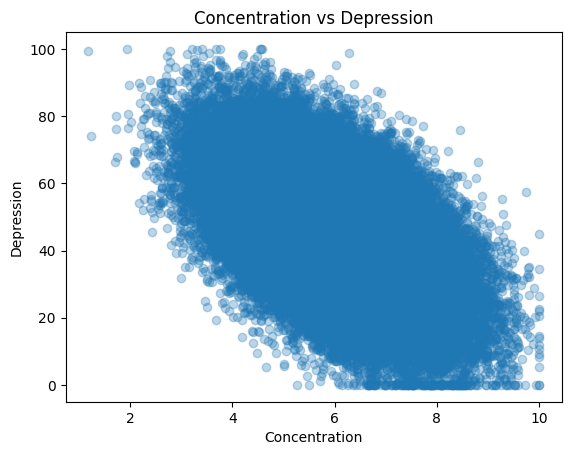

In [271]:
plt.scatter(df_sample["concentration"], df_sample["depression"], alpha=0.3)
plt.title("Concentration vs Depression")
plt.xlabel("Concentration")
plt.ylabel("Depression")
plt.show()

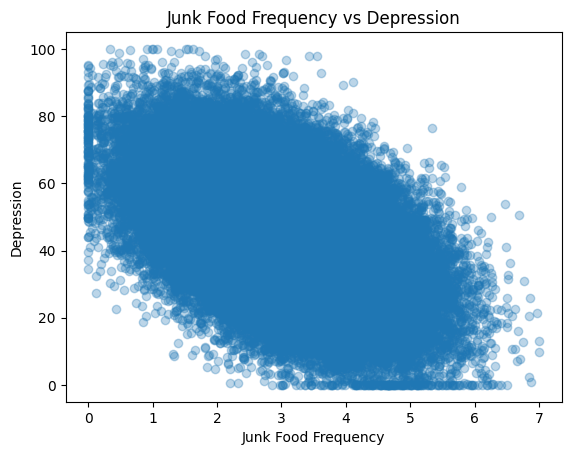

In [272]:
plt.scatter(df_sample["junk_food_frequency"], df_sample["depression"], alpha=0.3)
plt.title("Junk Food Frequency vs Depression")
plt.xlabel("Junk Food Frequency")
plt.ylabel("Depression")
plt.show()

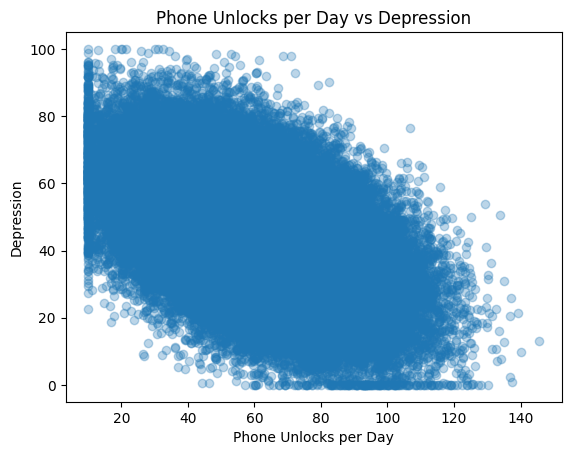

In [273]:
plt.scatter(df_sample["phone_unlocks_per_day"], df_sample["depression"], alpha=0.3)
plt.title("Phone Unlocks per Day vs Depression")
plt.xlabel("Phone Unlocks per Day")
plt.ylabel("Depression")
plt.show()

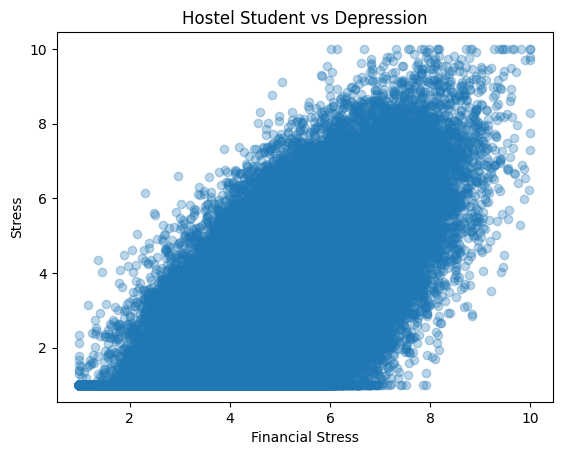

In [276]:
plt.scatter(df_sample["financial_stress"], df_sample["stress"], alpha=0.3)
plt.title("Hostel Student vs Depression")
plt.xlabel("Financial Stress")
plt.ylabel("Stress")
plt.show()

## Step 19: Interpretation of Visual Relationships

The scatter plots examine the selected features in three groups: the top positive correlates, the moderate/mixed features, and the top negative correlates from the correlation analysis.

- Strong positive relationships were observed for features such as `stress`, `anxiety`, `social_media_hours`, `screen_time`, and `financial_stress`, indicating that higher values in these factors are generally associated with higher depression.
- Moderate or mixed relationships were examined for features such as `gpa`, `attendance`, `physical_activity`, `extracurricular_hours`, and `part_time_hours`, which show weaker or more varied patterns with depression.
- Negative relationships were observed for features such as `sleep_hours`, `motivation`, `concentration`, `junk_food_frequency`, and `phone_unlocks_per_day`, suggesting that higher values in these factors tend to be associated with lower depression levels or different trends.

This interpretation reflects the code-generated scatter plots and the feature selection strategy based on the correlation bar chart.

However, it is important to note that these relationships are correlational and do not imply causation.

## Step 20: Summary of Key Findings

Based on the correlation analysis and scatter plot visualizations, several variables appear to have meaningful relationships with depression.

- `stress` and `anxiety` show the strongest positive relationships with depression.
- `social_media_hours`, `screen_time`, and `financial_stress` also appear positively associated with depression.
- `sleep_hours`, `motivation`, and `concentration` show negative relationships with depression.
- Some variables such as `gpa` and `attendance` show weaker or less clear patterns.

These findings suggest that behavioral and psychological variables may be more strongly associated with depression than purely academic indicators.

## Step 21: Feature Selection

## Selected Features for Visual Relationship Analysis

The following features were selected for scatter plot visualization based on their correlation with `depression` and their relevance to the research hypotheses.

### Strong Positive Relationship Features
These features showed stronger positive associations with depression:
- `stress`
- `anxiety`
- `social_media_hours`
- `screen_time`
- `financial_stress`

### Moderate or Mixed Relationship Features
These features showed weaker, moderate, or less clear relationships with depression:
- `gpa`
- `attendance`
- `physical_activity`
- `extracurricular_hours`
- `part_time_hours`
- `caffeine_mg`
- `hostel_student`

### Negative Relationship Features
These features showed negative associations with depression:
- `sleep_hours`
- `motivation`
- `concentration`
- `junk_food_frequency`
- `phone_unlocks_per_day`






In [ ]:
selected_features = [
    "stress",
    "anxiety",
    "social_media_hours",
    "screen_time",
    "financial_stress",
    "attendance",
    "physical_activity",
    "extracurricular_hours",
    "part_time_hours",
    "hostel_student",
    "sleep_hours",
    "motivation",
    "concentration",
    "junk_food_frequency",
    "phone_unlocks_per_day"
]
df_model = df_sample[selected_features + ["depression"]]
print(df_model.head())
print(df_model.shape)

          stress    anxiety  social_media_hours  screen_time  \
987231  1.427332  37.513250            4.171526     9.733560   
79954   1.000000  24.342316            5.386875    12.569374   
567130  1.000000  28.809320            4.088045     9.538772   
500891  1.621958  39.737465            3.018709     7.043655   
55399   2.252554  43.087550            4.656890    10.866076   

        financial_stress  sleep_hours  motivation  concentration  \
987231          4.877303     6.359227    5.131407       5.747458   
79954           3.922320     6.217529    7.225827       8.683245   
567130          3.899885     6.561132    6.452179       6.610812   
500891          3.752114     6.699014    6.308085       6.699507   
55399           5.031352     6.085952    4.116071       4.232833   

        physical_activity       gpa  depression  
987231           3.218983  0.516767   32.513250  
79954            2.408750  1.176744   19.342316  
567130           3.274637  0.815560   23.809320  
500891